## imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## read file

In [62]:
input_file="../DATA/hotel_bookings.csv"
df = pd.read_csv(input_file)

In [63]:
#df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  str    
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## cleanup

In [64]:
# Target encoding
df["is_canceled"] = df["is_canceled"].map({"no": 0, "yes": 1})

# Handle missing
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)
df["children"] = df["children"].fillna(0)

# Feature engineering
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df["arrival_month"] = pd.to_datetime(
    df["arrival_date_month"], format="%B"
).dt.month

df["room_mismatch"] = (
    df["reserved_room_type"] != df["assigned_room_type"]
).astype(int)

## Cancellation Distribution

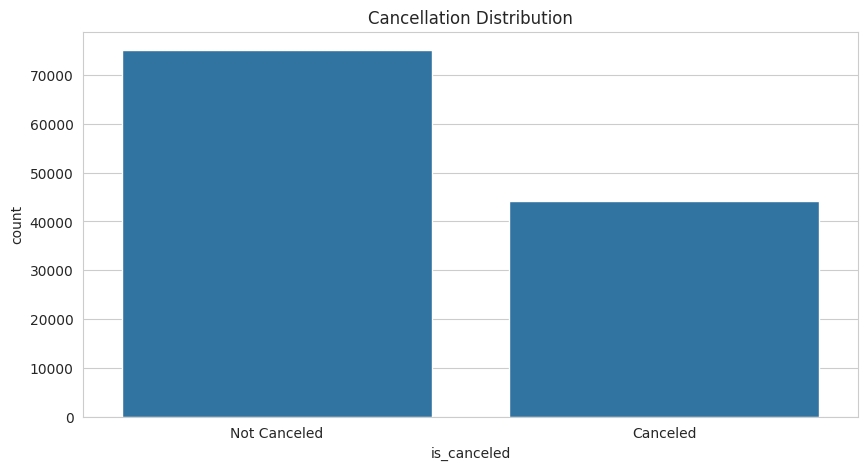

In [65]:
sns.countplot(x="is_canceled", data=df)
plt.title("Cancellation Distribution")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.show()

## Lead Time vs Cancellation

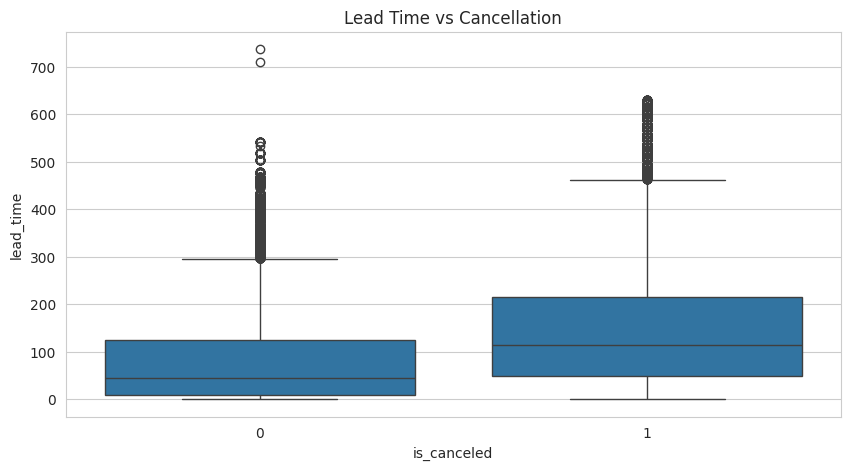

In [66]:
sns.boxplot(x="is_canceled", y="lead_time", data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

## Correlation Heatmap

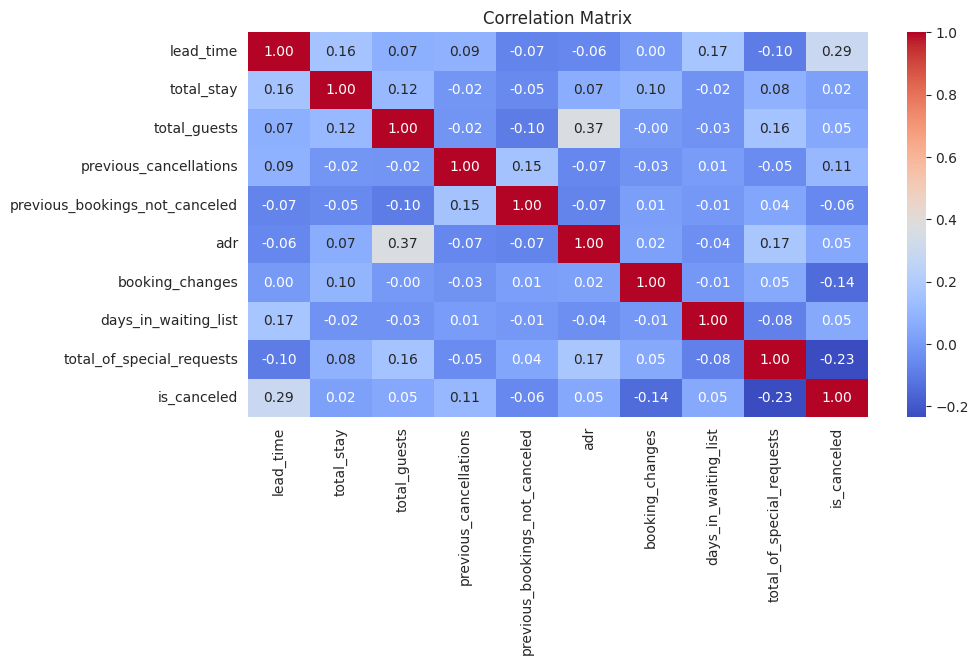

In [67]:
num_cols = [
    "lead_time", "total_stay", "total_guests",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr", "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests",
    "is_canceled"
]

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## feature importance using XGBoost

In [68]:
import xgboost as xgb


df = df.drop(columns=[
    "reservation_status",
    "reservation_status_date"
])

df = pd.get_dummies(df, drop_first=True)

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X, y)

ImportError: sklearn needs to be installed in order to use this module